# Random Forest model for Incidence

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay
import plotly.graph_objects as go
from sklearn.inspection import partial_dependence


In [23]:
df_ml= pd.read_csv('preparing_Incidence_data_for_ML.csv')

# preparing independent data & dependent

In [34]:
features= ['ln(GDP_per_capita)', 'urbanization_rate','pop_65', 'dm_high_aging_society','fertility','bmi', 'female_smoking', 'female_labor_rate', 'internet_penetration', 
                                   'log_gdp_is_oecd','female_labor_rate * is_oecd']
X= df_ml[features]
y= df_ml['incidence']

# dividing data to 3 groups:

In [25]:
x_train, x_test, y_train, y_test= train_test_split( X,y, test_size=0.2, random_state= 42)

# creating and learning the model

In [26]:
rf_incidence=RandomForestRegressor(n_estimators= 500, max_depth=10, min_samples_leaf=5, random_state =42, oob_score= True)
rf_incidence.fit(x_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=5, n_estimators=500,
                      oob_score=True, random_state=42)

# model performance and predictive power:

In [27]:
y_pred = rf_incidence.predict(x_test)
r2_incidence=r2_score(y_test, y_pred)

with open('incidence_ols_r2-within.txt', 'r') as f:
    ols_val = float(f.read())

print(f" R2-within in Ols regression: {ols_val:.4f}")
print("-" *30)
print(f" R2-within in RF : {r2_incidence:.4f}")
print("-" *30)
print("Note: The Ols regression focus on causal inference, while RF focus on prediction.")

 R2-within in Ols regression: 0.5499
------------------------------
 R2-within in RF : 0.9812
------------------------------
Note: The Ols regression focus on causal inference, while RF focus on prediction.


In [28]:
importances = rf_incidence.feature_importances_
incidences = np.argsort(importances)

# graphic format of model:

# Feature Importance Ranking:

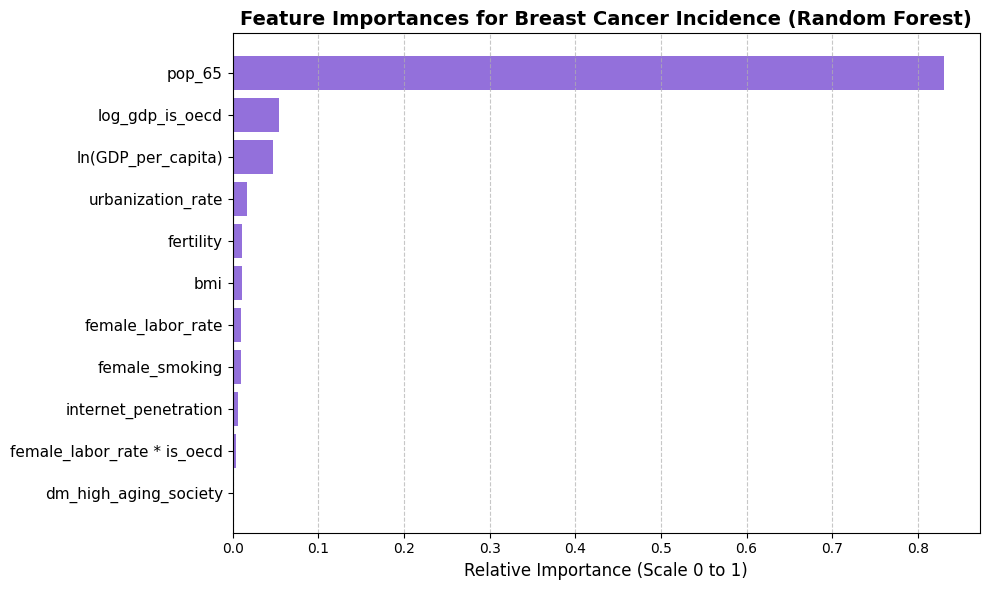

In [29]:
plt.figure(figsize=(10, 6))
plt.title('Feature Importances for Breast Cancer Incidence (Random Forest)', fontsize=14, fontweight='bold')
plt.barh(range(len(incidences)), importances[incidences], color='mediumpurple', align='center')
plt.yticks(range(len(incidences)), [features[i] for i in incidences], fontsize=11)
plt.xlabel('Relative Importance (Scale 0 to 1)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# oncovering non-linear Relationship:

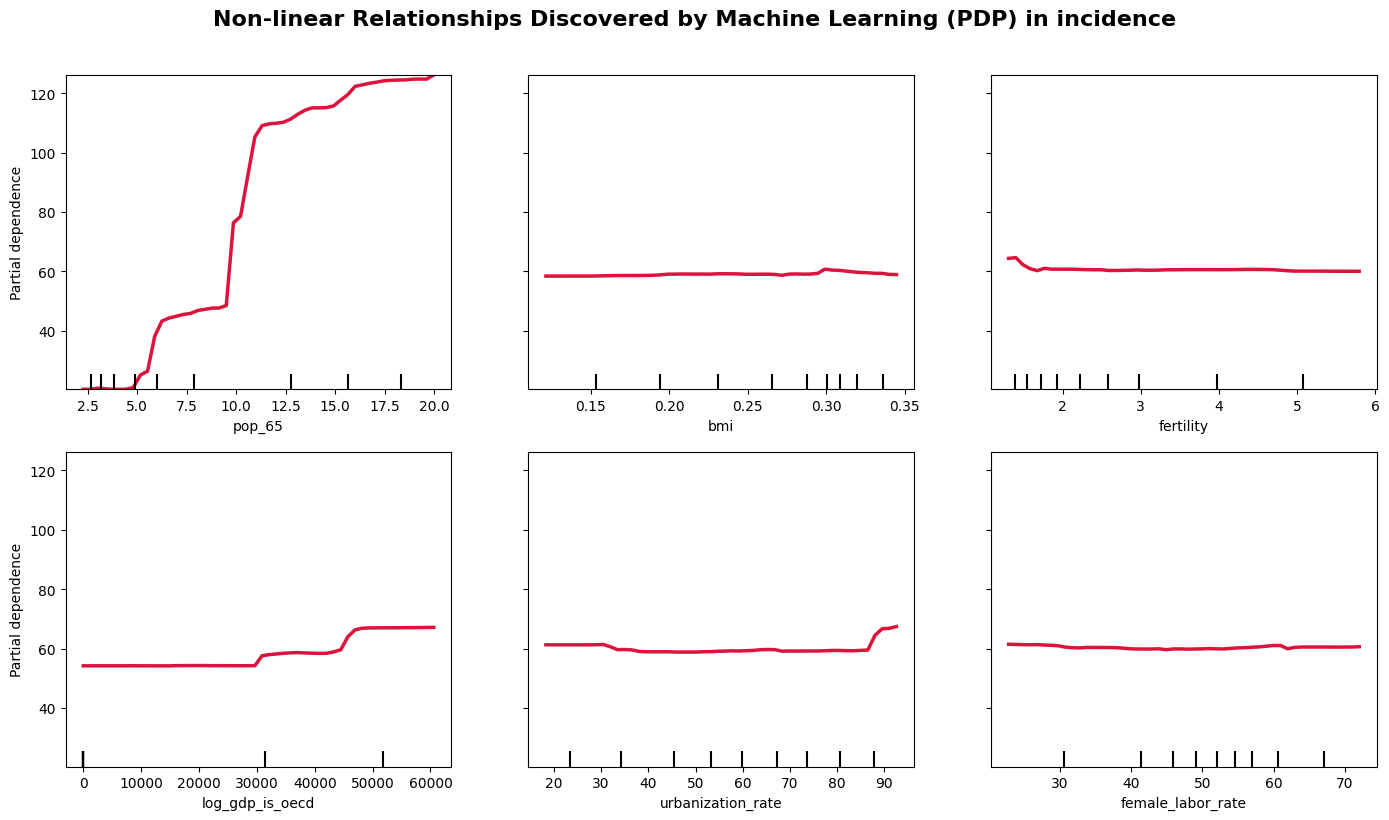

In [30]:
feature_lifestyle = ['pop_65', 'bmi','fertility']
feature_socioeconomic = ['log_gdp_is_oecd', 'urbanization_rate', 'female_labor_rate']
fig, ax = plt.subplots(figsize=(14, 8))
display = PartialDependenceDisplay.from_estimator(rf_incidence, x_train, 
feature_lifestyle+ feature_socioeconomic#+feature_infrastructure+ feature_intraction
,grid_resolution=50, ax=ax, line_kw={"color": "crimson", "linewidth": 2.5})
fig.suptitle('Non-linear Relationships Discovered by Machine Learning (PDP) in incidence', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Interactive 2DHeat map:

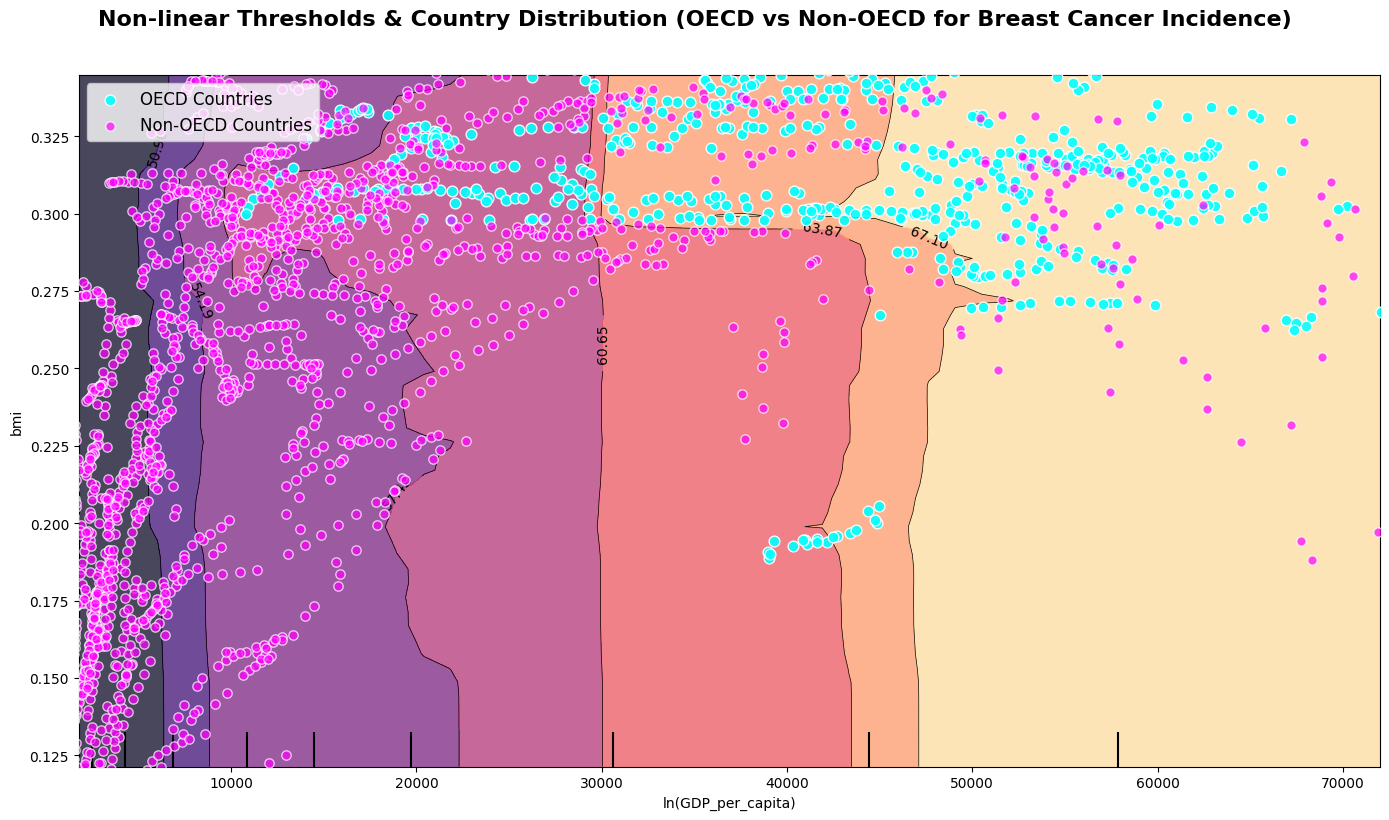

In [31]:
feature_infrastructure = [('ln(GDP_per_capita)', 'bmi')]
fig, ax = plt.subplots(figsize=(14, 8))

# using a default contour in the model of training data
display = PartialDependenceDisplay.from_estimator(
    rf_incidence, x_train, feature_infrastructure,
    grid_resolution=50,
    ax=ax,
    contour_kw={"cmap": "magma"})

target_ax = display.axes_[0, 0]

train_data_with_oecd = df_ml.loc[x_train.index]

oecd_points = train_data_with_oecd[train_data_with_oecd['is_oecd'] == 1]
non_oecd_points = train_data_with_oecd[train_data_with_oecd['is_oecd'] == 0]
# graphically differentiate OECD and non_OECD countries on the contour plot
#OECD_countries:
target_ax.scatter(
    oecd_points['ln(GDP_per_capita)'], oecd_points['bmi'],
    color='cyan', alpha=0.9, edgecolors='white', s=60, zorder=5,
    label='OECD Countries')
#non-OECD countries:
target_ax.scatter(
    non_oecd_points['ln(GDP_per_capita)'], non_oecd_points['bmi'],
    color='magenta', alpha=0.7, edgecolors='white', s=45, zorder=5,
    label='Non-OECD Countries')
# Adding guides and labels 
target_ax.legend(loc='upper left', fontsize=12)

fig.suptitle('Non-linear Thresholds & Country Distribution (OECD vs Non-OECD for Breast Cancer Incidence)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

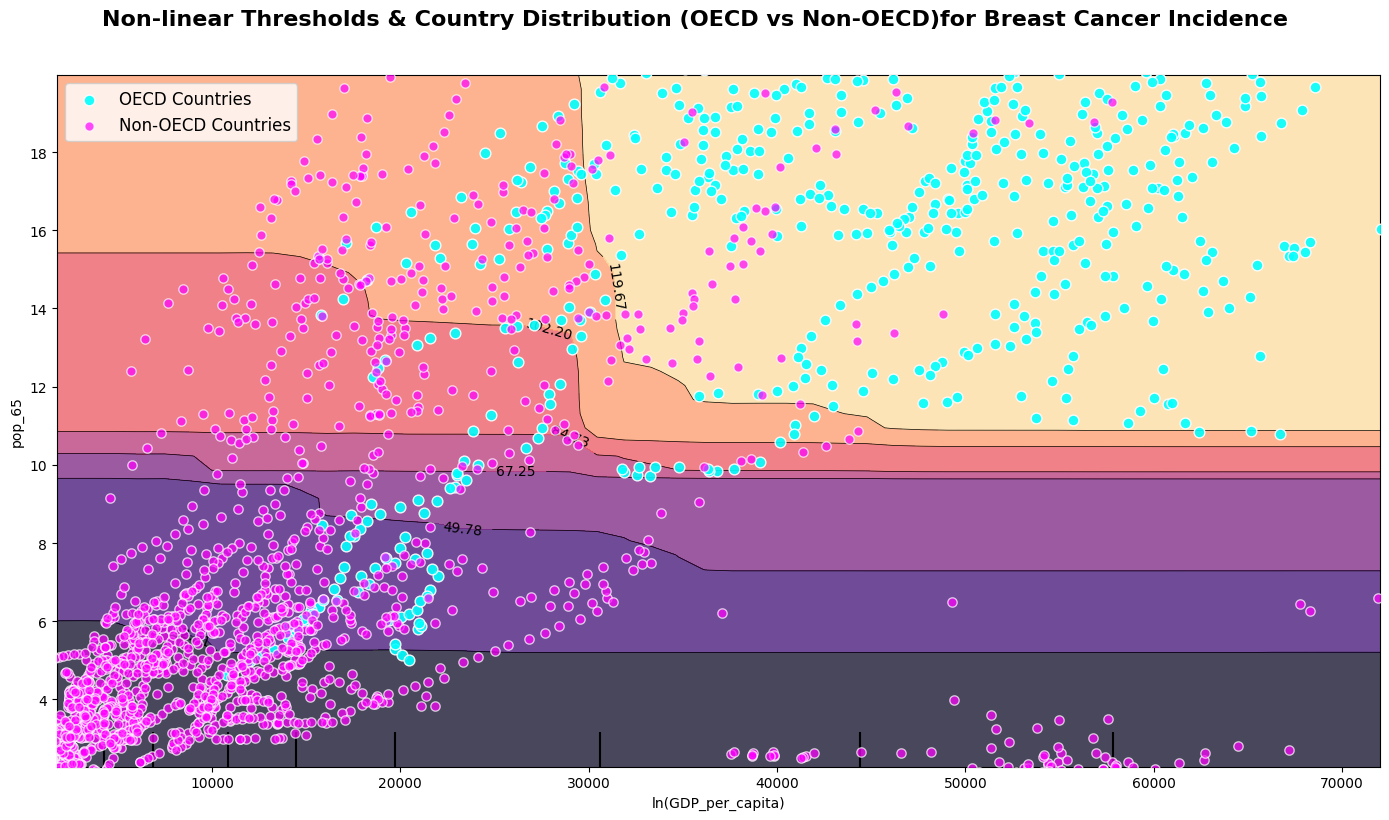

In [32]:
feature_infrastructure = [('ln(GDP_per_capita)', 'pop_65')]
fig, ax = plt.subplots(figsize=(14, 8))

#using a default contour in the model of training data
display = PartialDependenceDisplay.from_estimator(
    rf_incidence, x_train, feature_infrastructure,
    grid_resolution=50,
    ax=ax,
    contour_kw={"cmap": "magma"})
target_ax = display.axes_[0, 0]

train_data_with_oecd = df_ml.loc[x_train.index]
oecd_points = train_data_with_oecd[train_data_with_oecd['is_oecd'] == 1]
non_oecd_points = train_data_with_oecd[train_data_with_oecd['is_oecd'] == 0]
# graphically differentiate OECD and non_OECD countries on the contour plot
#OECD_countries:
target_ax.scatter(
    oecd_points['ln(GDP_per_capita)'], oecd_points['pop_65'],
    color='cyan', alpha=0.9, edgecolors='white', s=60, zorder=5,
    label='OECD Countries')
#non-OECD countries:
target_ax.scatter(
    non_oecd_points['ln(GDP_per_capita)'], non_oecd_points['pop_65'],
    color='magenta', alpha=0.7, edgecolors='white', s=45, zorder=5,
    label='Non-OECD Countries')
# Adding guides and labels 
target_ax.legend(loc='upper left', fontsize=12)
fig.suptitle('Non-linear Thresholds & Country Distribution (OECD vs Non-OECD)for Breast Cancer Incidence', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

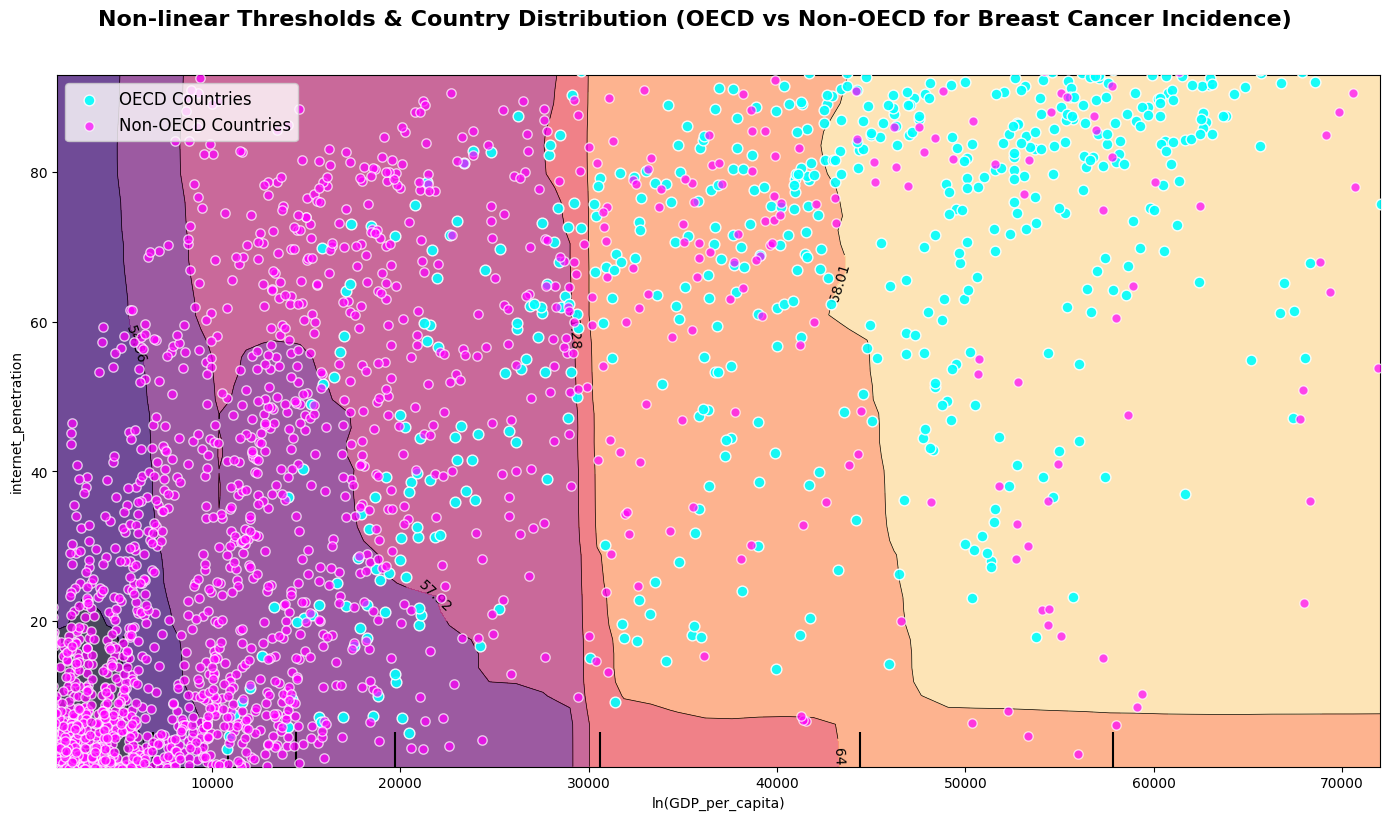

In [33]:
feature_infrastructure = [('ln(GDP_per_capita)', 'internet_penetration')]
fig, ax = plt.subplots(figsize=(14, 8))

#using a default contour in the model of training data
display = PartialDependenceDisplay.from_estimator(
    rf_incidence, x_train, feature_infrastructure,
    grid_resolution=50,
    ax=ax,
    contour_kw={"cmap": "magma"})

target_ax = display.axes_[0, 0]
train_data_with_oecd = df_ml.loc[x_train.index]

oecd_points = train_data_with_oecd[train_data_with_oecd['is_oecd'] == 1]
non_oecd_points = train_data_with_oecd[train_data_with_oecd['is_oecd'] == 0]

# graphically differentiate OECD and non_OECD countries on the contour plot
#OECD_countries:
target_ax.scatter(
    oecd_points['ln(GDP_per_capita)'], oecd_points['internet_penetration'],
    color='cyan', alpha=0.9, edgecolors='white', s=60, zorder=5,
    label='OECD Countries')

#non_OECD_countries:
target_ax.scatter(
    non_oecd_points['ln(GDP_per_capita)'], non_oecd_points['internet_penetration'],
    color='magenta', alpha=0.7, edgecolors='white', s=45, zorder=5,
    label='Non-OECD Countries')
# Adding guides and labels 
target_ax.legend(loc='upper left', fontsize=12)
fig.suptitle('Non-linear Thresholds & Country Distribution (OECD vs Non-OECD for Breast Cancer Incidence)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Define the features for the Interaction as 2D Partial Dependence Plot.